# Notebook 09
# PneumoXNet: Proposed Model for Multi-Class Pneumonia Classification

This notebook implements the proposed deep learning architecture, PneumoXNet, for multi-class pneumonia classification using chest X-ray images.

The proposed model is built upon EfficientNet-B2 and incorporates:
- CBAM (Convolutional Block Attention Module)
- Multi-Scale Feature Fusion
- Grad-CAM Explainability

The objective is to improve classification performance while providing better model interpretability.

In [3]:
# ============================================================
# Cell 1: Import Required Libraries
# ============================================================

# Standard Library
import copy
import random
import time
from pathlib import Path

# Data Processing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Progress Bar
from tqdm.auto import tqdm

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Pretrained Model
from torchvision.models import (
    efficientnet_b2,
    EfficientNet_B2_Weights
)

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.utils.class_weight import compute_class_weight

# Plot Style
sns.set_theme(
    style="whitegrid",
    context="notebook"
)

print("=" * 70)
print("Cell 1 : Required Libraries")
print(f"PyTorch Version : {torch.__version__}")
print("=" * 70)

Cell 1 : Required Libraries
PyTorch Version : 2.13.0+cu126


## Objectives

- Load the processed chest X-ray dataset
- Build the proposed PneumoXNet architecture
- Integrate CBAM attention mechanism
- Perform multi-scale feature fusion
- Train and validate the proposed model
- Evaluate on the independent test set
- Generate Grad-CAM visualizations
- Compare the proposed model with baseline models

In [4]:
# ============================================================
# Cell 2: Device Configuration
# ============================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 70)
print("Cell 2 : Device Configuration")
print("-" * 70)

print(f"Selected Device : {DEVICE}")

if torch.cuda.is_available():

    print(f"GPU Name     : {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version : {torch.version.cuda}")

    gpu_memory = (
        torch.cuda.get_device_properties(0).total_memory
        / (1024 ** 3)
    )

    print(f"GPU Memory   : {gpu_memory:.2f} GB")

else:
    print("Running on CPU")

print("=" * 70)

Cell 2 : Device Configuration
----------------------------------------------------------------------
Selected Device : cuda
GPU Name     : NVIDIA GeForce RTX 3050
CUDA Version : 12.6
GPU Memory   : 8.00 GB


## Workflow

1. Import Required Libraries
2. Device Configuration
3. Random Seed Initialization
4. Hyperparameter Configuration
5. Project Directory Configuration
6. Dataset Preparation
7. DataLoader Creation
8. Class Weight Computation
9. CBAM Module
10. Multi-Scale Feature Fusion Module
11. PneumoXNet Architecture
12. Model Training
13. Model Evaluation
14. Grad-CAM Visualization
15. Performance Comparison

In [5]:
# ============================================================
# Cell 3: Random Seed Configuration
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("=" * 70)
print("Cell 3 : Random Seed Configuration")
print("-" * 70)
print(f"Random Seed : {SEED}")
print("Reproducibility : Enabled")
print("=" * 70)

Cell 3 : Random Seed Configuration
----------------------------------------------------------------------
Random Seed : 42
Reproducibility : Enabled


In [6]:
# ============================================================
# Cell 4: Hyperparameter Configuration
# ============================================================

# Experiment Information

MODEL_NAME = "PneumoXNet"
MODEL_ID = "pneumoxnet"
MODEL_VERSION = "Proposed"
EXPERIMENT_NAME = "PneumoXNet_Proposed"

# Hyperparameters

IMAGE_SIZE = 260             # <-- 224 theke 260 kora hoyeche (B2-er native resolution)
BATCH_SIZE = 16
EPOCHS = 40                 # <-- 30 theke 40 kora hoyeche
LEARNING_RATE = 1e-4
NUM_CLASSES = 3
NUM_WORKERS = 0

CLASS_NAMES = [
    "BACTERIA",
    "NORMAL",
    "VIRUS"
]

print("=" * 70)
print("Cell 4 : Hyperparameter Configuration")
print("-" * 70)

print(f"Model Name      : {MODEL_NAME}")
print(f"Model ID        : {MODEL_ID}")
print(f"Version         : {MODEL_VERSION}")
print(f"Experiment      : {EXPERIMENT_NAME}")
print(f"Image Size      : {IMAGE_SIZE}")
print(f"Batch Size      : {BATCH_SIZE}")
print(f"Epochs          : {EPOCHS}")
print(f"Learning Rate   : {LEARNING_RATE}")
print(f"Number Classes  : {NUM_CLASSES}")

print("=" * 70)

Cell 4 : Hyperparameter Configuration
----------------------------------------------------------------------
Model Name      : PneumoXNet
Model ID        : pneumoxnet
Version         : Proposed
Experiment      : PneumoXNet_Proposed
Image Size      : 260
Batch Size      : 16
Epochs          : 40
Learning Rate   : 0.0001
Number Classes  : 3


In [7]:
# ============================================================
# Cell 5: Project Directory Configuration
# ============================================================

# Project Directories

PROJECT_ROOT = Path(
    "/mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI"
)

DATASET_DIR = PROJECT_ROOT / "dataset" / "processed_dataset"

MODELS_DIR = PROJECT_ROOT / "models"

RESULTS_DIR = PROJECT_ROOT / "results"

FIGURES_DIR = PROJECT_ROOT / "figures"

LOGS_DIR = PROJECT_ROOT / "logs"

# Create Directories

for directory in [
    MODELS_DIR,
    RESULTS_DIR,
    FIGURES_DIR,
    LOGS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

# Output Files

BEST_MODEL_PATH = MODELS_DIR / f"{MODEL_ID}_best.pth"

CHECKPOINT_PATH = MODELS_DIR / f"{MODEL_ID}_checkpoint.pth"

HISTORY_PATH = RESULTS_DIR / f"{MODEL_ID}_training_history.csv"

CLASSIFICATION_REPORT_PATH = (
    RESULTS_DIR / f"{MODEL_ID}_classification_report.txt"
)

CONFUSION_MATRIX_PATH = (
    FIGURES_DIR / f"{MODEL_ID}_confusion_matrix.png"
)

LOSS_CURVE_PATH = (
    FIGURES_DIR / f"{MODEL_ID}_loss_curve.png"
)

ACCURACY_CURVE_PATH = (
    FIGURES_DIR / f"{MODEL_ID}_accuracy_curve.png"
)

print("=" * 70)
print("Cell 5 : Project Directory Configuration")
print("-" * 70)

print(f"Project Root : {PROJECT_ROOT}")
print(f"Dataset      : {DATASET_DIR}")
print(f"Models       : {MODELS_DIR}")
print(f"Results      : {RESULTS_DIR}")
print(f"Figures      : {FIGURES_DIR}")
print(f"Logs         : {LOGS_DIR}")

print("=" * 70)

Cell 5 : Project Directory Configuration
----------------------------------------------------------------------
Project Root : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI
Dataset      : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/dataset/processed_dataset
Models       : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/models
Results      : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/results
Figures      : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/figures
Logs         : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/logs


In [8]:
# ============================================================
# Cell 6: Data Augmentation & Image Preprocessing
# ============================================================

train_transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(degrees=15),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.08, 0.08),
        scale=(0.90, 1.10)
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15
    ),

    transforms.ToTensor(),

    transforms.RandomErasing(
        p=0.25,
        scale=(0.02, 0.10)
    ),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )

])

valid_transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )

])

test_transform = valid_transform

print("=" * 70)
print("Cell 6 : Data Augmentation & Image Preprocessing")
print("-" * 70)
print(f"Training Image Size : {IMAGE_SIZE} x {IMAGE_SIZE}")
print("Training Transform  : Ready")
print("Validation Transform: Ready")
print("Test Transform      : Ready")
print("=" * 70)

Cell 6 : Data Augmentation & Image Preprocessing
----------------------------------------------------------------------
Training Image Size : 260 x 260
Training Transform  : Ready
Validation Transform: Ready
Test Transform      : Ready


In [9]:
# ============================================================
# Cell 7: Dataset Loading
# ============================================================

# -------------------------------
# Load Datasets
# -------------------------------

train_dataset = datasets.ImageFolder(
    root=DATASET_DIR / "train",
    transform=train_transform
)

valid_dataset = datasets.ImageFolder(
    root=DATASET_DIR / "validation",
    transform=valid_transform
)

test_dataset = datasets.ImageFolder(
    root=DATASET_DIR / "test",
    transform=test_transform
)

# -------------------------------
# Dataset Information
# -------------------------------

print("=" * 70)
print("Cell 7 : Dataset Loading")
print("-" * 70)

print(f"Training Images   : {len(train_dataset)}")
print(f"Validation Images : {len(valid_dataset)}")
print(f"Test Images       : {len(test_dataset)}")

print("-" * 70)

print(f"Classes           : {train_dataset.classes}")
print(f"Number of Classes : {len(train_dataset.classes)}")

print("-" * 70)

print("Class to Index Mapping:")

for class_name, class_index in train_dataset.class_to_idx.items():
    print(f"  {class_name:<10} -> {class_index}")

print("=" * 70)

Cell 7 : Dataset Loading
----------------------------------------------------------------------
Training Images   : 4099
Validation Images : 878
Test Images       : 879
----------------------------------------------------------------------
Classes           : ['BACTERIA', 'NORMAL', 'VIRUS']
Number of Classes : 3
----------------------------------------------------------------------
Class to Index Mapping:
  BACTERIA   -> 0
  NORMAL     -> 1
  VIRUS      -> 2


In [10]:
# ============================================================
# Cell 8: DataLoader Creation
# ============================================================

# Enable pin_memory only when using CUDA
PIN_MEMORY = torch.cuda.is_available()

# -------------------------------
# Training DataLoader
# -------------------------------

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False
)

# -------------------------------
# Validation DataLoader
# -------------------------------

valid_loader = DataLoader(
    dataset=valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False
)

# -------------------------------
# Test DataLoader
# -------------------------------

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False
)

# -------------------------------
# Display Information
# -------------------------------

print("=" * 70)
print("Cell 8 : DataLoader Creation")
print("-" * 70)

print(f"Training Batches   : {len(train_loader)}")
print(f"Validation Batches : {len(valid_loader)}")
print(f"Test Batches       : {len(test_loader)}")

print("-" * 70)

print(f"Batch Size         : {BATCH_SIZE}")
print(f"Number of Workers  : {NUM_WORKERS}")
print(f"Pin Memory         : {PIN_MEMORY}")

print("=" * 70)

Cell 8 : DataLoader Creation
----------------------------------------------------------------------
Training Batches   : 257
Validation Batches : 55
Test Batches       : 55
----------------------------------------------------------------------
Batch Size         : 16
Number of Workers  : 0
Pin Memory         : True


Cell 9 : Dataset Visualization
----------------------------------------------------------------------
Batch Image Shape : torch.Size([16, 3, 260, 260])
Batch Label Shape : torch.Size([16])


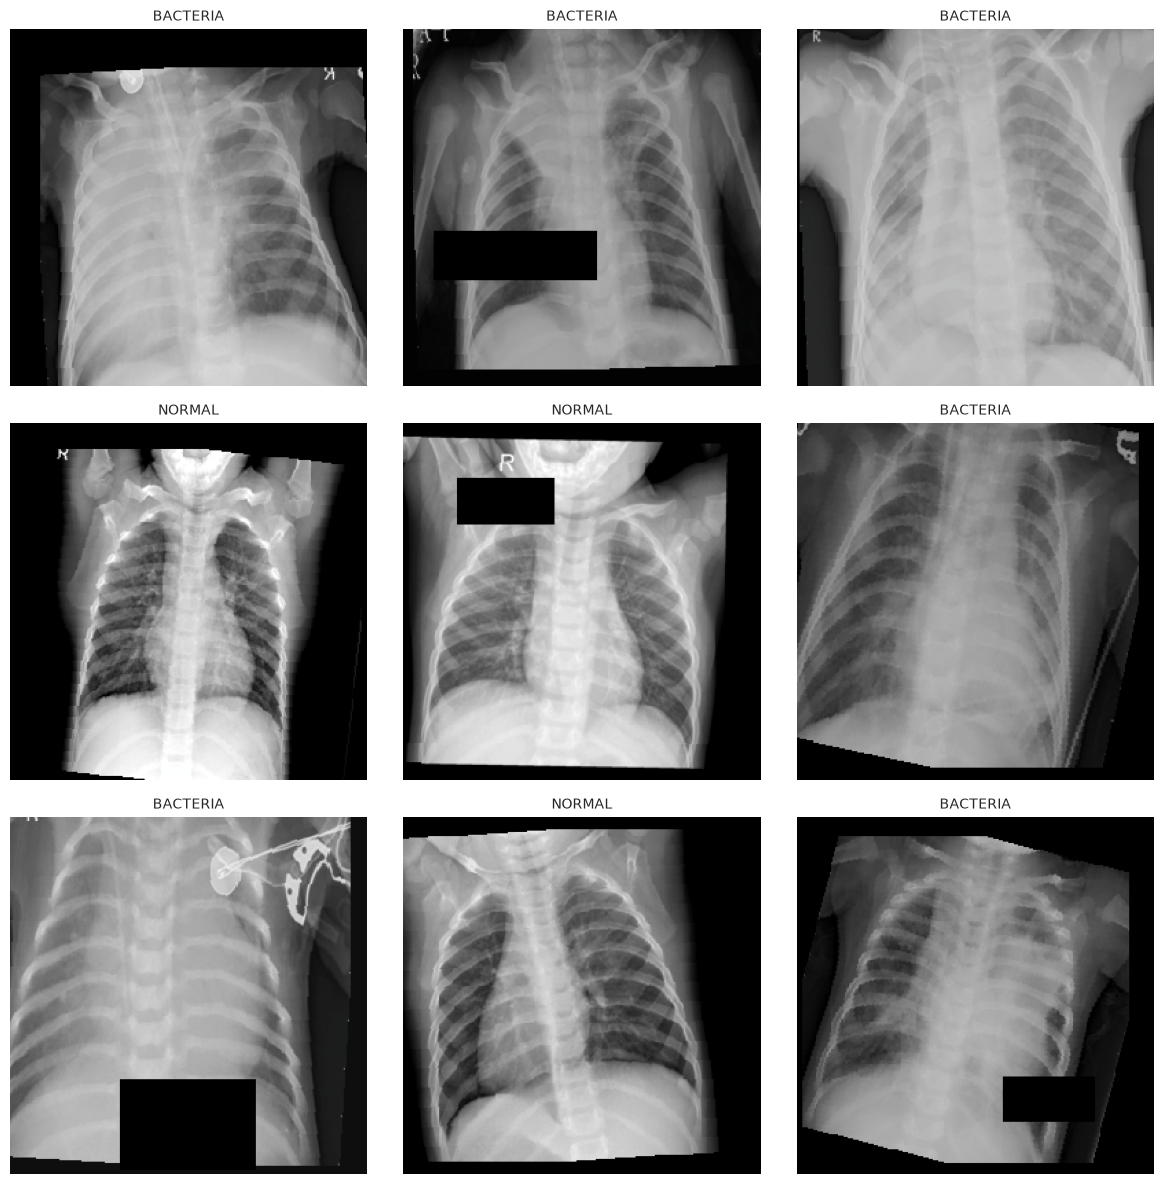

In [9]:
# ============================================================
# Cell 9: Dataset Visualization
# ============================================================

# Get one batch of training images
images, labels = next(iter(train_loader))

# Display batch information
print("=" * 70)
print("Cell 9 : Dataset Visualization")
print("-" * 70)

print(f"Batch Image Shape : {images.shape}")
print(f"Batch Label Shape : {labels.shape}")

print("=" * 70)

# ImageNet Normalization Statistics
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

# Display 9 sample images
plt.figure(figsize=(12, 12))

for i in range(9):

    image = images[i].permute(1, 2, 0).cpu().numpy()

    # De-normalize image
    image = (image * std) + mean
    image = np.clip(image, 0, 1)

    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(CLASS_NAMES[labels[i].item()], fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

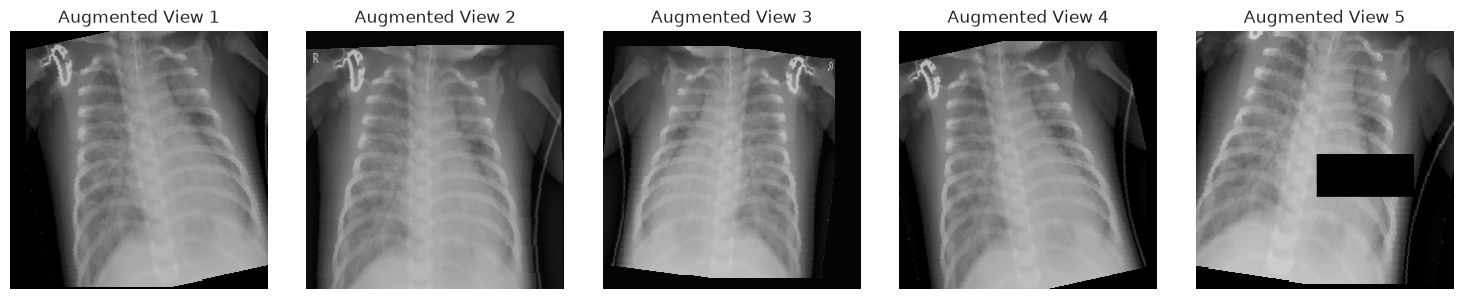

In [11]:
import matplotlib.pyplot as plt
from PIL import Image

raw_img_path = train_dataset.samples[0][0]
raw_img = Image.open(raw_img_path).convert("RGB")

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    aug_tensor = train_transform(raw_img)
    img_show = aug_tensor.permute(1, 2, 0).numpy()
    img_show = (img_show * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]
    axes[i].imshow(img_show.clip(0, 1))
    axes[i].set_title(f"Augmented View {i+1}")
    axes[i].axis("off")
plt.tight_layout()
plt.savefig("augmentation_samples_fixed.png", dpi=150)
plt.show()

In [10]:
# ============================================================
# Cell 10: CBAM (Convolutional Block Attention Module)
# ============================================================

import torch
import torch.nn as nn

# --------------------------------------------------
# Channel Attention
# --------------------------------------------------

class ChannelAttention(nn.Module):

    def __init__(self, in_channels, reduction_ratio=16):

        super(ChannelAttention, self).__init__()

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.shared_mlp = nn.Sequential(
            nn.Conv2d(
                in_channels,
                in_channels // reduction_ratio,
                kernel_size=1,
                bias=False
            ),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                in_channels // reduction_ratio,
                in_channels,
                kernel_size=1,
                bias=False
            )
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        avg_out = self.shared_mlp(self.avg_pool(x))

        max_out = self.shared_mlp(self.max_pool(x))

        attention = self.sigmoid(avg_out + max_out)

        return x * attention


# --------------------------------------------------
# Spatial Attention
# --------------------------------------------------

class SpatialAttention(nn.Module):

    def __init__(self, kernel_size=7):

        super(SpatialAttention, self).__init__()

        self.conv = nn.Conv2d(
            2,
            1,
            kernel_size=kernel_size,
            padding=kernel_size // 2,
            bias=False
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        avg_out = torch.mean(
            x,
            dim=1,
            keepdim=True
        )

        max_out, _ = torch.max(
            x,
            dim=1,
            keepdim=True
        )

        combined = torch.cat(
            [avg_out, max_out],
            dim=1
        )

        attention = self.sigmoid(
            self.conv(combined)
        )

        return x * attention


# --------------------------------------------------
# CBAM Module
# --------------------------------------------------

class CBAM(nn.Module):

    def __init__(
        self,
        in_channels,
        reduction_ratio=16
    ):

        super(CBAM, self).__init__()

        self.channel_attention = ChannelAttention(
            in_channels,
            reduction_ratio
        )

        self.spatial_attention = SpatialAttention()

    def forward(self, x):

        x = self.channel_attention(x)

        x = self.spatial_attention(x)

        return x


print("=" * 70)
print("Cell 10 : CBAM Module Created Successfully")
print("=" * 70)

Cell 10 : CBAM Module Created Successfully


In [11]:
# ============================================================
# Cell 11: Multi-Scale Feature Fusion Module
# ============================================================

import torch
import torch.nn as nn

# --------------------------------------------------
# Multi-Scale Feature Fusion (Bottleneck + Dilated Conv version)
# --------------------------------------------------

class MultiScaleFeatureFusion(nn.Module):

    def __init__(self, in_channels, reduction=4):

        super(MultiScaleFeatureFusion, self).__init__()

        mid_channels = in_channels // reduction

        # Channel reduction (bottleneck) - parameter onek kome jabe
        self.reduce = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True)
        )

        self.branch_1x1 = nn.Sequential(
            nn.Conv2d(mid_channels, mid_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True)
        )

        self.branch_3x3 = nn.Sequential(
            nn.Conv2d(mid_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True)
        )

        # Dilated conv - kom parameter e effective receptive field barbe
        self.branch_5x5 = nn.Sequential(
            nn.Conv2d(mid_channels, mid_channels, kernel_size=3, padding=2, dilation=2, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True)
        )

        self.fusion = nn.Sequential(
            nn.Conv2d(mid_channels * 3, in_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        x = self.reduce(x)

        feature_1 = self.branch_1x1(x)
        feature_2 = self.branch_3x3(x)
        feature_3 = self.branch_5x5(x)

        fused = torch.cat(
            [feature_1, feature_2, feature_3],
            dim=1
        )

        output = self.fusion(fused)

        return output


print("=" * 70)
print("Cell 11 : Multi-Scale Feature Fusion Module Created Successfully (Lightweight)")
print("=" * 70)

Cell 11 : Multi-Scale Feature Fusion Module Created Successfully (Lightweight)


In [12]:
# ============================================================
# Cell 12A: Adaptive Feature Fusion + Residual Enhancement
# ============================================================

import torch
import torch.nn as nn


# --------------------------------------------------
# Conv + BN + ReLU Block
# --------------------------------------------------

class ConvBNReLU(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size=1,
        stride=1,
        padding=0
    ):

        super().__init__()

        self.block = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size,
                stride,
                padding,
                bias=False
            ),

            nn.BatchNorm2d(out_channels),

            nn.ReLU(inplace=True)

        )

    def forward(self, x):

        return self.block(x)


# --------------------------------------------------
# Adaptive Feature Fusion
# --------------------------------------------------

class AdaptiveFeatureFusion(nn.Module):

    def __init__(self, channels):

        super().__init__()

        self.weight_generator = nn.Sequential(

            nn.Conv2d(
                channels * 2,
                channels,
                kernel_size=1,
                bias=False
            ),

            nn.BatchNorm2d(channels),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                channels,
                channels,
                kernel_size=1,
                bias=False
            ),

            nn.Sigmoid()

        )

    def forward(
        self,
        cbam_feature,
        multiscale_feature
    ):

        # Concatenate Features

        fused = torch.cat(
            [
                cbam_feature,
                multiscale_feature
            ],
            dim=1
        )

        # Generate Adaptive Weights

        weights = self.weight_generator(fused)

        # Weighted Fusion

        output = (
            weights * cbam_feature
            +
            (1.0 - weights) * multiscale_feature
        )

        return output


# --------------------------------------------------
# Residual Feature Enhancement
# --------------------------------------------------

class ResidualEnhancement(nn.Module):

    def __init__(self, channels):

        super().__init__()

        self.refine = nn.Sequential(

            nn.Conv2d(
                channels,
                channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(channels),

            nn.ReLU(inplace=True)

        )

    def forward(self, x):

        identity = x

        out = self.refine(x)

        out = out + identity

        return out


# --------------------------------------------------
# Verification
# --------------------------------------------------

print("=" * 70)
print("Cell 12A : Adaptive Feature Fusion + Residual Enhancement")
print("-" * 70)

aff = AdaptiveFeatureFusion(1408)
residual = ResidualEnhancement(1408)

print("Adaptive Feature Fusion  : OK")
print("Residual Enhancement     : OK")

print("=" * 70)

Cell 12A : Adaptive Feature Fusion + Residual Enhancement
----------------------------------------------------------------------
Adaptive Feature Fusion  : OK
Residual Enhancement     : OK


In [13]:
# ============================================================
# Cell 12B: PneumoXNet Architecture
# ============================================================

class PneumoXNet(nn.Module):

    def __init__(self, num_classes=3):

        super(PneumoXNet, self).__init__()

        weights = EfficientNet_B2_Weights.DEFAULT
        backbone = efficientnet_b2(weights=weights)

        self.backbone = backbone.features
        self.feature_channels = 1408

        self.cbam = CBAM(
            in_channels=self.feature_channels
        )

        self.multiscale = MultiScaleFeatureFusion(
            in_channels=self.feature_channels
        )

        self.aff = AdaptiveFeatureFusion(
            channels=self.feature_channels
        )

        self.residual = ResidualEnhancement(
            channels=self.feature_channels
        )

        self.pool = nn.AdaptiveAvgPool2d(1)

        # --------------------------------------------------
        # Improved Classification Head (Stronger Regularization)
        # --------------------------------------------------

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Dropout(0.5),

            nn.Linear(
                self.feature_channels,
                512
            ),

            nn.ReLU(inplace=True),

            nn.Dropout(0.4),

            nn.Linear(
                512,
                num_classes
            )

        )

    def forward(self, x):

        features = self.backbone(x)

        cbam_features = self.cbam(features)

        multiscale_features = self.multiscale(features)

        fused_features = self.aff(
            cbam_features,
            multiscale_features
        )

        enhanced_features = self.residual(fused_features)

        pooled_features = self.pool(enhanced_features)

        output = self.classifier(pooled_features)

        return output


print("=" * 70)
print("Cell 12B : PneumoXNet Architecture")
print("-" * 70)

_dummy_model = PneumoXNet(num_classes=NUM_CLASSES)

_dummy_input = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE)

_dummy_output = _dummy_model(_dummy_input)

print(f"Input Shape       : {tuple(_dummy_input.shape)}")
print(f"Output Shape      : {tuple(_dummy_output.shape)}")

print("-" * 70)

print("Backbone          : EfficientNet-B2")
print("Attention         : CBAM")
print("Fusion            : Multi-Scale + Adaptive Feature Fusion")
print("Enhancement       : Residual")
print("Classifier        : FC(1408 -> 512 -> 3)")

print("-" * 70)
print("PneumoXNet Architecture Built Successfully")

del _dummy_model, _dummy_input, _dummy_output

print("=" * 70)

Cell 12B : PneumoXNet Architecture
----------------------------------------------------------------------
Input Shape       : (2, 3, 260, 260)
Output Shape      : (2, 3)
----------------------------------------------------------------------
Backbone          : EfficientNet-B2
Attention         : CBAM
Fusion            : Multi-Scale + Adaptive Feature Fusion
Enhancement       : Residual
Classifier        : FC(1408 -> 512 -> 3)
----------------------------------------------------------------------
PneumoXNet Architecture Built Successfully


In [14]:
# ============================================================
# Cell 13: Class Weight Computation
# ============================================================

# -------------------------------
# Compute Class Weights
# -------------------------------

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_dataset.targets),
    y=train_dataset.targets
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(DEVICE)

# -------------------------------
# Display Class Weights
# -------------------------------

print("=" * 70)
print("Cell 13 : Class Weight Computation")
print("-" * 70)

for class_name, weight in zip(CLASS_NAMES, class_weights):
    print(f"{class_name:<10}: {weight.item():.4f}")

print("=" * 70)

Cell 13 : Class Weight Computation
----------------------------------------------------------------------
BACTERIA  : 0.7021
NORMAL    : 1.2332
VIRUS     : 1.3075


In [15]:
# ============================================================
# Cell 14: PneumoXNet Model Initialization
# ============================================================

model = PneumoXNet(
    num_classes=NUM_CLASSES
)

model = model.to(DEVICE)

# -------------------------------
# Model Information
# -------------------------------

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("=" * 70)
print("Cell 14 : PneumoXNet Model Initialization")
print("-" * 70)

print(f"Model Name           : {MODEL_NAME}")
print(f"Backbone              : EfficientNet-B2 (ImageNet Pretrained)")
print(f"Output Classes       : {NUM_CLASSES}")

print("-" * 70)

print(f"Total Parameters     : {total_parameters:,}")
print(f"Trainable Parameters : {trainable_parameters:,}")

print("-" * 70)

print(f"Model Device         : {DEVICE}")

print("=" * 70)

Cell 14 : PneumoXNet Model Initialization
----------------------------------------------------------------------
Model Name           : PneumoXNet
Backbone              : EfficientNet-B2 (ImageNet Pretrained)
Output Classes       : 3
----------------------------------------------------------------------
Total Parameters     : 36,809,319
Trainable Parameters : 36,809,319
----------------------------------------------------------------------
Model Device         : cuda


In [16]:
# ============================================================
# Cell 15: Training Configuration
# ============================================================

# -------------------------------
# Loss Function (Label Smoothing)
# -------------------------------

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1
)

# -------------------------------
# Optimizer (Differential Learning Rate)
# -------------------------------

new_module_params = (
    list(model.cbam.parameters())
    + list(model.multiscale.parameters())
    + list(model.aff.parameters())
    + list(model.residual.parameters())
    + list(model.classifier.parameters())
)

optimizer = optim.AdamW(
    [
        {
            "params": model.backbone.parameters(),
            "lr": LEARNING_RATE * 0.7,
            "weight_decay": 2e-4
        },
        {
            "params": new_module_params,
            "lr": LEARNING_RATE,
            "weight_decay": 5e-4
        }
    ]
)

# -------------------------------
# Learning Rate Scheduler
# -------------------------------

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=4,
    min_lr=1e-6
)

print("=" * 70)
print("Cell 15 : Training Configuration")
print("-" * 70)

print(f"Loss Function           : {criterion.__class__.__name__} (label_smoothing=0.1)")
print(f"Optimizer               : {optimizer.__class__.__name__}")
print(f"Backbone LR             : {LEARNING_RATE * 0.7}")
print(f"New Modules LR          : {LEARNING_RATE}")
print(f"Backbone Weight Decay   : 2e-4")
print(f"New Modules Weight Decay: 5e-4")
print("Scheduler               : ReduceLROnPlateau")
print("LR Reduction            : x0.5")
print("Scheduler Patience      : 4")
print("Minimum LR              : 1e-6")

print("=" * 70)

Cell 15 : Training Configuration
----------------------------------------------------------------------
Loss Function           : CrossEntropyLoss (label_smoothing=0.1)
Optimizer               : AdamW
Backbone LR             : 7e-05
New Modules LR          : 0.0001
Backbone Weight Decay   : 2e-4
New Modules Weight Decay: 5e-4
Scheduler               : ReduceLROnPlateau
LR Reduction            : x0.5
Scheduler Patience      : 4
Minimum LR              : 1e-6


In [17]:
# ============================================================
# Cell 16: Training Function
# ============================================================

def train_one_epoch(model, dataloader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    progress_bar = tqdm(
        dataloader,
        desc="Training",
        leave=False
    )

    for images, labels in progress_bar:

        images = images.to(device)
        labels = labels.to(device)

        # Forward Pass
        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        # Backward Pass
        loss.backward()

        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)

        _, predictions = torch.max(outputs, dim=1)

        correct_predictions += (predictions == labels).sum().item()

        total_samples += labels.size(0)

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    epoch_loss = running_loss / total_samples

    epoch_accuracy = correct_predictions / total_samples

    return epoch_loss, epoch_accuracy


print("=" * 70)
print("Cell 16 : Training Function Created Successfully")
print("=" * 70)

Cell 16 : Training Function Created Successfully


In [18]:
# ============================================================
# Cell 17: Validation Function
# ============================================================

def validate_one_epoch(model, dataloader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():

        progress_bar = tqdm(
            dataloader,
            desc="Validation",
            leave=False
        )

        for images, labels in progress_bar:

            images = images.to(device)
            labels = labels.to(device)

            # Forward Pass
            outputs = model(images)

            loss = criterion(outputs, labels)

            # Statistics
            running_loss += loss.item() * images.size(0)

            _, predictions = torch.max(outputs, dim=1)

            correct_predictions += (predictions == labels).sum().item()

            total_samples += labels.size(0)

            progress_bar.set_postfix(
                loss=f"{loss.item():.4f}"
            )

    epoch_loss = running_loss / total_samples

    epoch_accuracy = correct_predictions / total_samples

    return epoch_loss, epoch_accuracy


print("=" * 70)
print("Cell 17 : Validation Function Created Successfully")
print("=" * 70)

Cell 17 : Validation Function Created Successfully


In [19]:
# ============================================================
# Cell 18: Training Initialization
# ============================================================

history = {
    "epoch": [],
    "train_loss": [],
    "train_accuracy": [],
    "valid_loss": [],
    "valid_accuracy": [],
    "learning_rate": []
}

best_val_accuracy = 0.0
best_val_loss = float("inf")
best_epoch = 0
best_loss_epoch = 0

early_stopping_patience = 10
early_stopping_counter = 0

BEST_MODEL_BY_LOSS_PATH = MODELS_DIR / f"{MODEL_ID}_best_by_loss.pth"

start_time = time.time()

print("=" * 70)
print("Cell 18 : Training Initialization")
print("-" * 70)
print(f"Best Validation Accuracy : {best_val_accuracy:.4f}")
print(f"Best Validation Loss     : {best_val_loss:.4f}")
print(f"Early Stopping Patience  : {early_stopping_patience}")
print(f"Training History         : Initialized")
print("=" * 70)

Cell 18 : Training Initialization
----------------------------------------------------------------------
Best Validation Accuracy : 0.0000
Best Validation Loss     : inf
Early Stopping Patience  : 10
Training History         : Initialized


In [20]:
# ============================================================
# Cell 19: Model Training Loop
# ============================================================

print("=" * 70)
print(f"Training {MODEL_NAME}")
print("=" * 70)

for epoch in range(EPOCHS):

    epoch_start_time = time.time()

    print(f"\nEpoch [{epoch + 1}/{EPOCHS}]")
    print("-" * 70)

    train_loss, train_accuracy = train_one_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=DEVICE
    )

    valid_loss, valid_accuracy = validate_one_epoch(
        model=model,
        dataloader=valid_loader,
        criterion=criterion,
        device=DEVICE
    )

    scheduler.step(valid_accuracy)

    current_lr = optimizer.param_groups[0]["lr"]

    history["epoch"].append(epoch + 1)
    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["valid_loss"].append(valid_loss)
    history["valid_accuracy"].append(valid_accuracy)
    history["learning_rate"].append(current_lr)

    # --------------------------------------------------
    # Save Best Model (by Accuracy)
    # --------------------------------------------------

    if valid_accuracy > best_val_accuracy:

        best_val_accuracy = valid_accuracy
        best_epoch = epoch + 1
        early_stopping_counter = 0

        torch.save(
            model.state_dict(),
            BEST_MODEL_PATH
        )

        print("✅ Best model (by accuracy) updated.")

    else:

        early_stopping_counter += 1

    # --------------------------------------------------
    # Save Best Model (by Loss)
    # --------------------------------------------------

    if valid_loss < best_val_loss:

        best_val_loss = valid_loss
        best_loss_epoch = epoch + 1

        torch.save(
            model.state_dict(),
            BEST_MODEL_BY_LOSS_PATH
        )

        print("✅ Best model (by loss) updated.")

    checkpoint = {
        "epoch": epoch + 1,
        "model_name": MODEL_NAME,
        "model_id": MODEL_ID,
        "model_version": MODEL_VERSION,
        "experiment_name": EXPERIMENT_NAME,

        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),

        "best_epoch": best_epoch,
        "best_val_accuracy": best_val_accuracy,
        "best_loss_epoch": best_loss_epoch,
        "best_val_loss": best_val_loss,

        "history": history
    }

    torch.save(
        checkpoint,
        CHECKPOINT_PATH
    )

    pd.DataFrame(history).to_csv(
        HISTORY_PATH,
        index=False
    )

    epoch_time = time.time() - epoch_start_time

    print(f"Train Loss      : {train_loss:.4f}")
    print(f"Train Accuracy  : {train_accuracy:.4f}")

    print(f"Valid Loss      : {valid_loss:.4f}")
    print(f"Valid Accuracy  : {valid_accuracy:.4f}")

    print(f"Learning Rate   : {current_lr:.6f}")
    print(f"Epoch Time      : {epoch_time:.2f} sec")

    print(f"Best Accuracy   : {best_val_accuracy:.4f} (epoch {best_epoch})")
    print(f"Best Loss       : {best_val_loss:.4f} (epoch {best_loss_epoch})")

    if early_stopping_counter >= early_stopping_patience:

        print("\n🛑 Early Stopping Triggered")
        break

training_time = time.time() - start_time

history_df = pd.DataFrame(history)

history_df.to_csv(
    HISTORY_PATH,
    index=False
)

print("\n" + "=" * 70)
print("Training Completed")
print("-" * 70)

print(f"Best Epoch (Accuracy)   : {best_epoch}")
print(f"Best Validation Accuracy: {best_val_accuracy:.4f}")
print(f"Best Epoch (Loss)       : {best_loss_epoch}")
print(f"Best Validation Loss    : {best_val_loss:.4f}")
print(f"Total Training Time     : {training_time / 60:.2f} minutes")

print("=" * 70)

Training PneumoXNet

Epoch [1/40]
----------------------------------------------------------------------


Training:   0%|          | 0/257 [00:00<?, ?it/s]

Validation:   0%|          | 0/55 [00:00<?, ?it/s]

✅ Best model (by accuracy) updated.
✅ Best model (by loss) updated.
Train Loss      : 0.7713
Train Accuracy  : 0.7158
Valid Loss      : 0.7113
Valid Accuracy  : 0.7927
Learning Rate   : 0.000070
Epoch Time      : 140.52 sec
Best Accuracy   : 0.7927 (epoch 1)
Best Loss       : 0.7113 (epoch 1)

Epoch [2/40]
----------------------------------------------------------------------


Training:   0%|          | 0/257 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/55 [00:00<?, ?it/s]

Train Loss      : 0.3617
Train Accuracy  : 0.9758
Valid Loss      : 0.6927
Valid Accuracy  : 0.8314
Learning Rate   : 0.000009
Epoch Time      : 142.67 sec
Best Accuracy   : 0.8405 (epoch 22)
Best Loss       : 0.6451 (epoch 5)

Epoch [32/40]
----------------------------------------------------------------------


Training:   0%|          | 0/257 [00:00<?, ?it/s]

Validation:   0%|          | 0/55 [00:00<?, ?it/s]

Train Loss      : 0.3662
Train Accuracy  : 0.9741
Valid Loss      : 0.6998
Valid Accuracy  : 0.8292
Learning Rate   : 0.000004
Epoch Time      : 143.50 sec
Best Accuracy   : 0.8405 (epoch 22)
Best Loss       : 0.6451 (epoch 5)

🛑 Early Stopping Triggered

Training Completed
----------------------------------------------------------------------
Best Epoch (Accuracy)   : 22
Best Validation Accuracy: 0.8405
Best Epoch (Loss)       : 5
Best Validation Loss    : 0.6451
Total Training Time     : 77.52 minutes


In [29]:
# ============================================================
# Cell 20: Load Best Model
# ============================================================

MODEL_TO_TEST = BEST_MODEL_PATH
# MODEL_TO_TEST = BEST_MODEL_BY_LOSS_PATH

model.load_state_dict(
    torch.load(
        MODEL_TO_TEST,
        map_location=DEVICE
    )
)

model.eval()

print("=" * 70)
print("Cell 20 : Best Model Loaded")
print("-" * 70)

print(f"Model Name            : {MODEL_NAME}")
print(f"Model Path            : {MODEL_TO_TEST}")

if MODEL_TO_TEST == BEST_MODEL_PATH:
    print(f"Model Type            : Best Validation Accuracy")
    print(f"Best Validation Acc   : {best_val_accuracy:.4f}")
    print(f"Best Epoch            : {best_epoch}")
else:
    print(f"Model Type            : Best Validation Loss")
    print(f"Best Validation Loss  : {best_val_loss:.4f}")
    print(f"Best Epoch            : {best_loss_epoch}")

print("=" * 70)

Cell 20 : Best Model Loaded
----------------------------------------------------------------------
Model Name            : PneumoXNet
Model Path            : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/models/pneumoxnet_best.pth
Model Type            : Best Validation Accuracy
Best Validation Acc   : 0.8405
Best Epoch            : 22


In [30]:
# ============================================================
# Cell 21: Test Set Evaluation
# ============================================================

model.eval()

test_loss = 0.0
correct_predictions = 0
total_samples = 0

all_predictions = []
all_labels = []
all_probabilities = []

with torch.no_grad():

    progress_bar = tqdm(
        test_loader,
        desc="Testing",
        leave=False
    )

    for images, labels in progress_bar:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)

        loss = criterion(outputs, labels)

        probabilities = torch.softmax(outputs, dim=1)

        _, predictions = torch.max(outputs, dim=1)

        test_loss += loss.item() * images.size(0)

        correct_predictions += (
            predictions == labels
        ).sum().item()

        total_samples += labels.size(0)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_probabilities.extend(
            probabilities.cpu().numpy()
        )

# --------------------------------------------------
# Final Metrics
# --------------------------------------------------

test_loss /= total_samples

test_accuracy = correct_predictions / total_samples

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)
all_probabilities = np.array(all_probabilities)

print("=" * 70)
print("Cell 21 : Test Set Evaluation")
print("-" * 70)

print(f"Test Samples      : {total_samples}")
print(f"Test Loss         : {test_loss:.4f}")
print(f"Test Accuracy     : {test_accuracy:.4f}")

print("-" * 70)

print(f"Prediction Shape  : {all_predictions.shape}")
print(f"Label Shape       : {all_labels.shape}")
print(f"Probability Shape : {all_probabilities.shape}")

print("=" * 70)

Testing:   0%|          | 0/55 [00:00<?, ?it/s]

Cell 21 : Test Set Evaluation
----------------------------------------------------------------------
Test Samples      : 879
Test Loss         : 0.6301
Test Accuracy     : 0.8487
----------------------------------------------------------------------
Prediction Shape  : (879,)
Label Shape       : (879,)
Probability Shape : (879, 3)


In [31]:
# ============================================================
# Cell 22: Classification Report
# ============================================================

# -------------------------------
# Generate Classification Report
# -------------------------------

report = classification_report(
    all_labels,
    all_predictions,
    target_names=CLASS_NAMES,
    digits=4
)

# -------------------------------
# Save Report
# -------------------------------

with open(CLASSIFICATION_REPORT_PATH, "w") as file:
    file.write(report)

# -------------------------------
# Display Report
# -------------------------------

print("=" * 70)
print("Cell 22 : Classification Report")
print("-" * 70)

print(report)

print("-" * 70)
print(f"Saved To : {CLASSIFICATION_REPORT_PATH}")

print("=" * 70)

Cell 22 : Classification Report
----------------------------------------------------------------------
              precision    recall  f1-score   support

    BACTERIA     0.8558    0.8537    0.8547       417
      NORMAL     0.9623    0.9664    0.9644       238
       VIRUS     0.7143    0.7143    0.7143       224

    accuracy                         0.8487       879
   macro avg     0.8441    0.8448    0.8445       879
weighted avg     0.8486    0.8487    0.8486       879

----------------------------------------------------------------------
Saved To : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/results/pneumoxnet_classification_report.txt


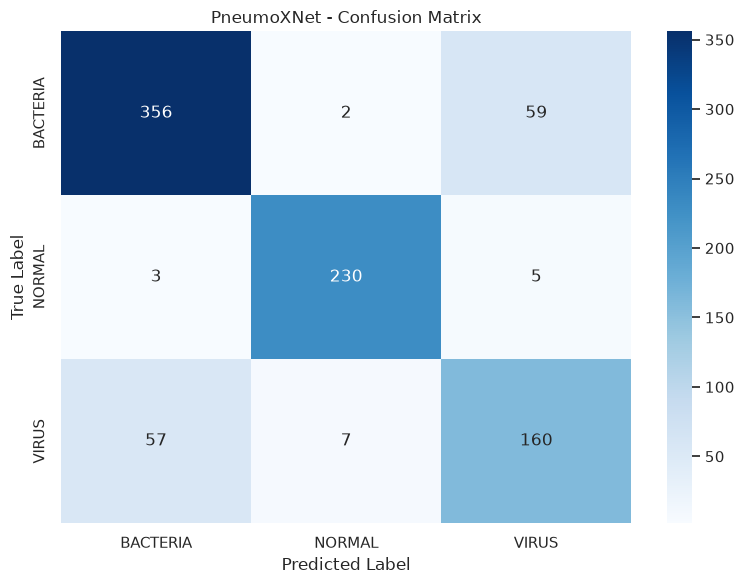

Cell 23 : Confusion Matrix
----------------------------------------------------------------------
Saved To : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/figures/pneumoxnet_confusion_matrix.png


In [32]:
# ============================================================
# Cell 23: Confusion Matrix
# ============================================================

cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title(f"{MODEL_NAME} - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()

plt.savefig(
    CONFUSION_MATRIX_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("=" * 70)
print("Cell 23 : Confusion Matrix")
print("-" * 70)
print(f"Saved To : {CONFUSION_MATRIX_PATH}")
print("=" * 70)

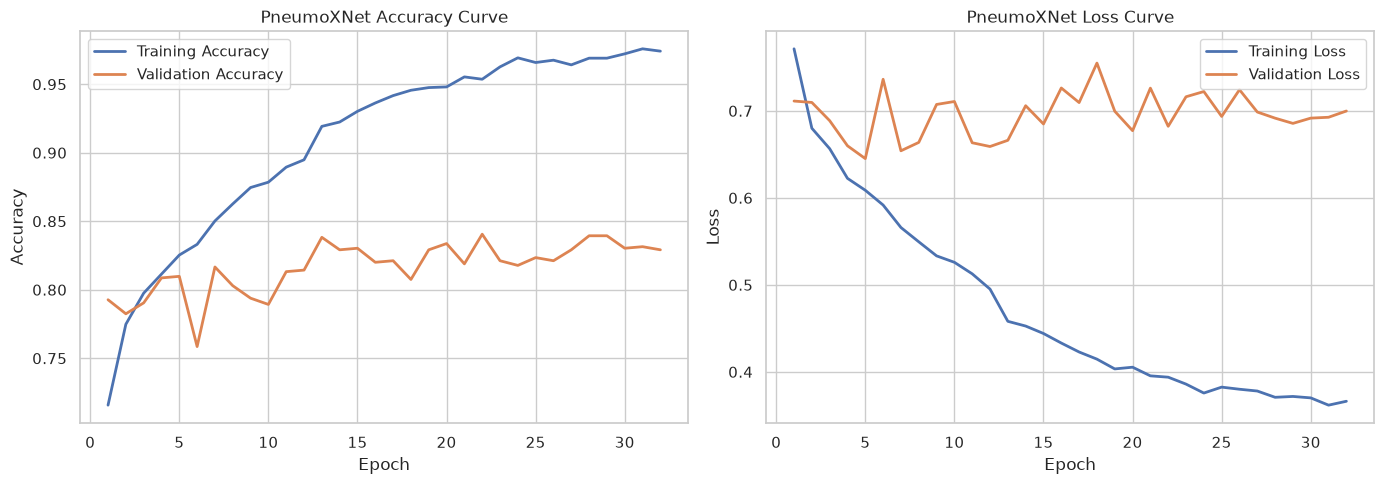

Cell 24 : Accuracy & Loss Curves
----------------------------------------------------------------------
Accuracy Curve Saved : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/figures/pneumoxnet_accuracy_curve.png
Loss Curve Saved     : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/figures/pneumoxnet_loss_curve.png


In [33]:
# ============================================================
# Cell 24: Accuracy and Loss Curves
# ============================================================

history_df = pd.DataFrame(history)

plt.figure(figsize=(14, 5))

# -------------------------------
# Accuracy Curve
# -------------------------------

plt.subplot(1, 2, 1)

plt.plot(
    history_df["epoch"],
    history_df["train_accuracy"],
    label="Training Accuracy",
    linewidth=2
)

plt.plot(
    history_df["epoch"],
    history_df["valid_accuracy"],
    label="Validation Accuracy",
    linewidth=2
)

plt.title(f"{MODEL_NAME} Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# -------------------------------
# Loss Curve
# -------------------------------

plt.subplot(1, 2, 2)

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Training Loss",
    linewidth=2
)

plt.plot(
    history_df["epoch"],
    history_df["valid_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.title(f"{MODEL_NAME} Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()

plt.savefig(
    ACCURACY_CURVE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    LOSS_CURVE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("=" * 70)
print("Cell 24 : Accuracy & Loss Curves")
print("-" * 70)
print(f"Accuracy Curve Saved : {ACCURACY_CURVE_PATH}")
print(f"Loss Curve Saved     : {LOSS_CURVE_PATH}")
print("=" * 70)

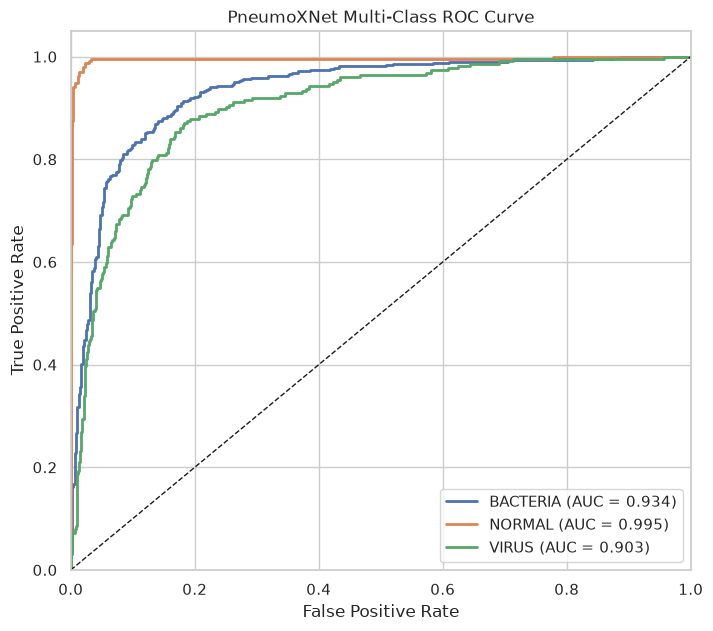

Cell 25 : ROC Curve
----------------------------------------------------------------------
Saved To : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/figures/pneumoxnet_roc_curve.png


In [34]:
# ============================================================
# Cell 25: Multi-Class ROC Curve
# ============================================================

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# -------------------------------
# Binarize Labels
# -------------------------------

binary_labels = label_binarize(
    all_labels,
    classes=range(NUM_CLASSES)
)

# -------------------------------
# Plot ROC Curves
# -------------------------------

plt.figure(figsize=(8, 7))

for i in range(NUM_CLASSES):

    fpr, tpr, _ = roc_curve(
        binary_labels[:, i],
        all_probabilities[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{CLASS_NAMES[i]} (AUC = {roc_auc:.3f})"
    )

# Random Classifier

plt.plot(
    [0, 1],
    [0, 1],
    "k--",
    linewidth=1
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(f"{MODEL_NAME} Multi-Class ROC Curve")

plt.legend(loc="lower right")

plt.grid(True)

ROC_CURVE_PATH = FIGURES_DIR / f"{MODEL_ID}_roc_curve.png"

plt.savefig(
    ROC_CURVE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("=" * 70)
print("Cell 25 : ROC Curve")
print("-" * 70)
print(f"Saved To : {ROC_CURVE_PATH}")
print("=" * 70)

In [36]:
# ============================================================
# Cell 26: Save Training History
# ============================================================

history_df = pd.DataFrame(history)

history_df.to_csv(
    HISTORY_PATH,
    index=False
)

print("=" * 70)
print("Cell 26 : Training History Saved")
print("-" * 70)

print(f"Total Epochs           : {len(history_df)}")
print(f"Best Epoch             : {best_epoch}")
print(f"Best Validation Acc    : {best_val_accuracy:.4f}")

print("-" * 70)

print(f"Saved To : {HISTORY_PATH}")

print("=" * 70)

Cell 26 : Training History Saved
----------------------------------------------------------------------
Total Epochs           : 32
Best Epoch             : 22
Best Validation Acc    : 0.8405
----------------------------------------------------------------------
Saved To : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/results/pneumoxnet_training_history.csv


In [28]:
# ============================================================
# Cell 27: Notebook Summary
# ============================================================

print("=" * 70)
print("Notebook Summary")
print("=" * 70)

print("\nModel")
print("-" * 70)
print(f"Model Name            : {MODEL_NAME}")
print(f"Backbone               : EfficientNet-B2")
print(f"Novel Modules          : CBAM + Multi-Scale Fusion + Adaptive Fusion + Residual Enhancement")
print(f"Dataset                : Kermany Chest X-ray (Pediatric)")
print(f"Classes                : {NUM_CLASSES}")

print("\nPerformance")
print("-" * 70)
print(f"Best Validation Acc   : {best_val_accuracy:.4f}")
print(f"Test Accuracy         : {test_accuracy:.4f}")
print(f"Best Epoch            : {best_epoch}")

print("\nSaved Files")
print("-" * 70)
print(f"Best Model            : {BEST_MODEL_PATH}")
print(f"Training History      : {HISTORY_PATH}")
print(f"Classification Report : {CLASSIFICATION_REPORT_PATH}")
print(f"Confusion Matrix      : {CONFUSION_MATRIX_PATH}")
print(f"Accuracy Curve        : {ACCURACY_CURVE_PATH}")
print(f"Loss Curve            : {LOSS_CURVE_PATH}")
print(f"ROC Curve             : {ROC_CURVE_PATH}")

print("\nNext Steps")
print("-" * 70)
print("-> Notebook 10: Grad-CAM Explainability")
print("-> Final baseline vs. PneumoXNet comparison table")
print("-> Paper: Methodology, Results, Discussion sections")

print("\nPneumoXNet Training & Evaluation Completed Successfully!")

print("=" * 70)

Notebook Summary

Model
----------------------------------------------------------------------
Model Name            : PneumoXNet
Backbone               : EfficientNet-B2
Novel Modules          : CBAM + Multi-Scale Fusion + Adaptive Fusion + Residual Enhancement
Dataset                : Kermany Chest X-ray (Pediatric)
Classes                : 3

Performance
----------------------------------------------------------------------
Best Validation Acc   : 0.8405
Test Accuracy         : 0.8487
Best Epoch            : 22

Saved Files
----------------------------------------------------------------------
Best Model            : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/models/pneumoxnet_best.pth
Training History      : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/results/pneumoxnet_training_history.csv
Classification Report : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/results/pneumoxnet_classification_report.txt
Confusion Matrix      : /m